# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.3 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [8]:
images = np.load('images.npy')

labels = pd.read_csv('labels.csv')

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [9]:
def helmet_check(label_val):
    val = label_val.iloc[0] if hasattr(label_val, 'iloc') else label_val
    if val == 1:
        return "Helmet"
    else:
        return "No Helmet"

In [10]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

In [11]:
print(labels.head(10))
print(labels.columns)

   label
0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
Index(['label'], dtype='object')


In [12]:
print(images.shape)
print(labels.shape)
print(images[0].shape)

(4125, 200, 200, 3)
(4125, 1)
(200, 200, 3)


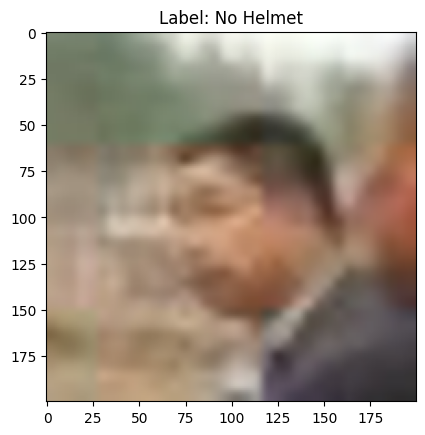

In [13]:
plt.imshow(images[0])
plt.title(f"Label: {helmet_check(labels.iloc[0].item())}")
plt.show()

In [16]:
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

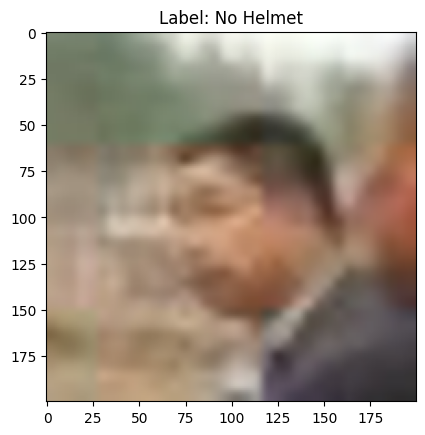

In [17]:
plt.imshow(images[0])
plt.title(f"Label: {helmet_check(labels.iloc[0].item())}")
plt.show()

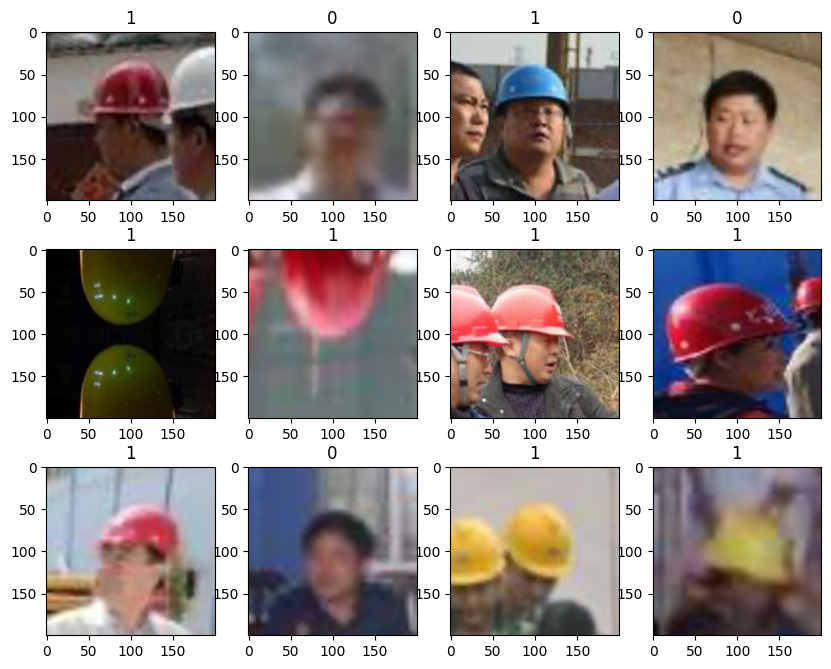

In [19]:
plot_images(images,labels)

## Checking for class imbalance


Helmet:     3161 (76.6%)
No Helmet:  964 (23.4%)


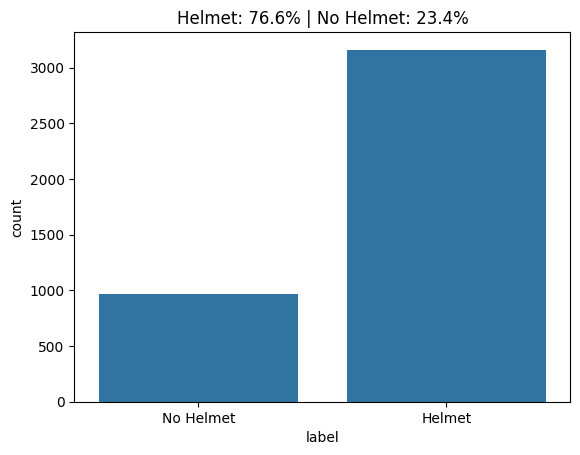

In [20]:
counts = labels['label'].value_counts()
percentages = labels['label'].value_counts(normalize=True) * 100

print(f"Helmet:     {counts[1]} ({percentages[1]:.1f}%)")
print(f"No Helmet:  {counts[0]} ({percentages[0]:.1f}%)")

sns.countplot(x=labels['label'])
plt.xticks([0, 1], ['No Helmet', 'Helmet'])
plt.title(f"Helmet: {percentages[1]:.1f}% | No Helmet: {percentages[0]:.1f}%")
plt.show()

only around a quarter of the images show someone with no helmet so there is a decent imbalance between the two.


# **Data Preprocessing**

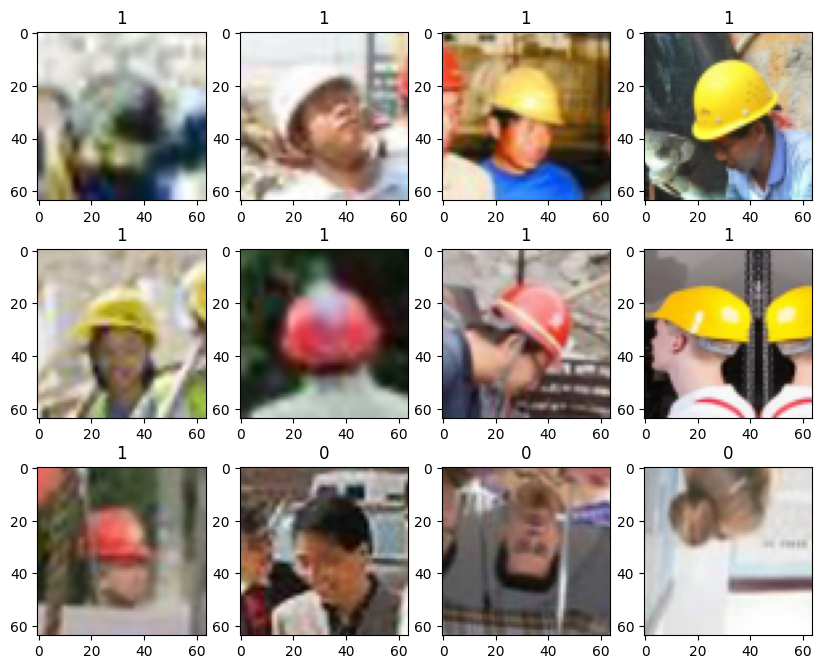

In [21]:
dimensions = (64, 64)
images_decreased = [cv2.resize(img, dimensions, interpolation=cv2.INTER_AREA) for img in images]
images_decreased = np.array(images_decreased)
plot_images(images_decreased, labels)

In [22]:
print(images_decreased[0].shape)
print(len(images_decreased))

(64, 64, 3)
4125


In [23]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images_decreased)):
    images_gb.append(cv2.GaussianBlur(images_decreased[i], ksize =(3,3),sigmaX =  0))
images_gb_np = np.array(images_gb)

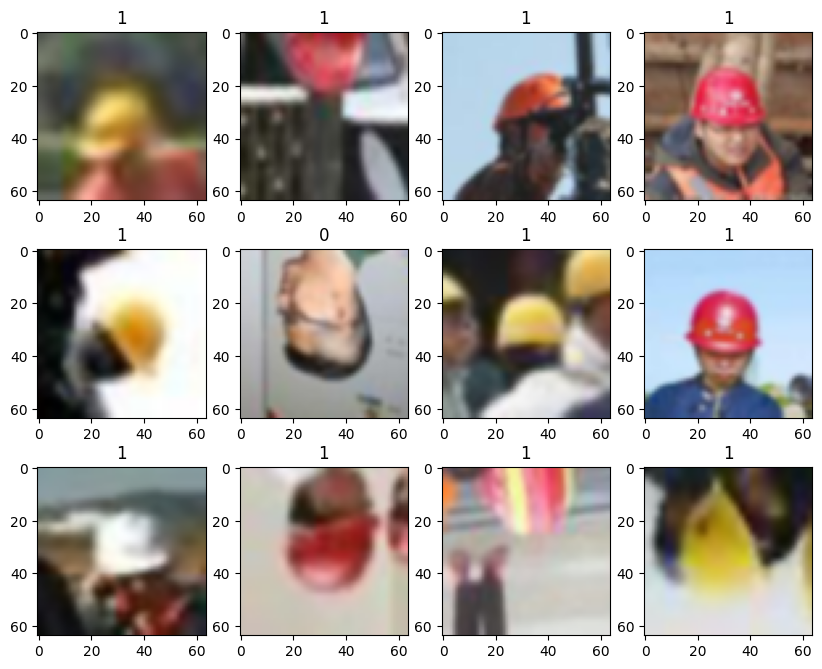

In [25]:
plot_images(images_gb_np, labels)

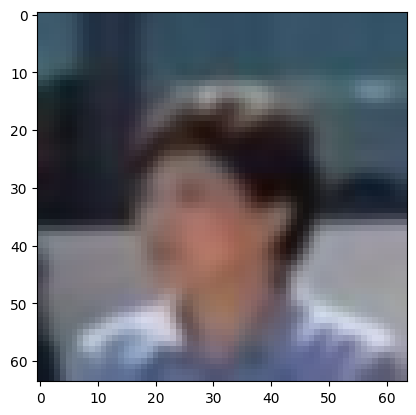

In [26]:
plt.imshow(images_gb[3]);


### Splitting the dataset



In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    np.array(images_decreased), labels['label'],
    test_size=0.2, random_state=42, stratify=labels['label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

In [29]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3300, 64, 64, 3) (3300,)
(412, 64, 64, 3) (412,)
(413, 64, 64, 3) (413,)


### Data Normalization

In [30]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

In [31]:
y_train_encoded = y_train.values.astype('float32').reshape(-1, 1)
y_val_encoded   = y_val.values.astype('float32').reshape(-1, 1)
y_test_encoded  = y_test.values.astype('float32').reshape(-1, 1)

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [32]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [33]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [59]:
def line_graph(results):
  plt.plot(results.history['accuracy'])
  plt.plot(results.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [35]:
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras import optimizers
from tensorflow.keras import losses

In [36]:
num_classes = labels['label'].nunique()
image_size = X_train_normalized[0].size
shape = X_train_normalized.shape[1:]

In [37]:
model_1 = Sequential()
model_1.add(Input(shape=(shape[0], shape[1], shape[2])))
model_1.add(Flatten())
model_1.add(Dense(256, activation='relu', kernel_initializer='he_uniform'))
model_1.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_1.add(Dense(64, activation='relu', kernel_initializer='he_uniform'))
model_1.add(Dense(32, activation='relu', kernel_initializer='he_uniform'))
model_1.add(Dense(1, activation='sigmoid'))


In [38]:
adam = Adam()
model_1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])


In [39]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,189,249 (12.17 MB)

 Trainable params: 3,189,249 (12.17 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_1 = model_1.fit(
    X_train_normalized, y_train_encoded,
    validation_data=(X_val_normalized, y_val_encoded),
    batch_size=32,
    epochs=20,
    verbose=2
)

Epoch 1/20
104/104 - 4s - 41ms/step - accuracy: 0.7636 - loss: 0.6759 - val_accuracy: 0.7087 - val_loss: 0.5559
Epoch 2/20
104/104 - 1s - 10ms/step - accuracy: 0.8258 - loss: 0.4042 - val_accuracy: 0.7646 - val_loss: 0.5086
Epoch 3/20
104/104 - 1s - 13ms/step - accuracy: 0.8309 - loss: 0.3849 - val_accuracy: 0.8034 - val_loss: 0.4156
Epoch 4/20
104/104 - 1s - 9ms/step - accuracy: 0.8494 - loss: 0.3546 - val_accuracy: 0.8447 - val_loss: 0.3249
Epoch 5/20
104/104 - 1s - 8ms/step - accuracy: 0.8500 - loss: 0.3492 - val_accuracy: 0.8277 - val_loss: 0.3637
Epoch 6/20
104/104 - 1s - 8ms/step - accuracy: 0.8561 - loss: 0.3359 - val_accuracy: 0.8592 - val_loss: 0.3385
Epoch 7/20
104/104 - 1s - 8ms/step - accuracy: 0.8621 - loss: 0.3215 - val_accuracy: 0.8447 - val_loss: 0.3551
Epoch 8/20
104/104 - 1s - 7ms/step - accuracy: 0.8673 - loss: 0.3099 - val_accuracy: 0.8592 - val_loss: 0.3257
Epoch 9/20
104/104 - 1s - 8ms/step - accuracy: 0.8724 - loss: 0.3020 - val_accuracy: 0.8398 - val_loss: 0.339

In [45]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized, y_train)
model_1_val_perf = model_performance_classification(model_1, X_val_normalized, y_val)

print("Train performance metrics")
print(model_1_train_perf)

print("Val performance metrics")
print(model_1_val_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.841818  0.841818   0.841818  0.841818
Val performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.842233  0.842233   0.842233  0.842233


### Visualizing the predictions

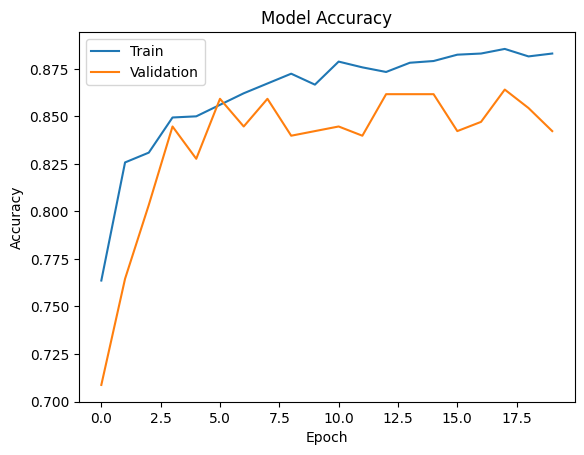

In [60]:
line_graph(history_1)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


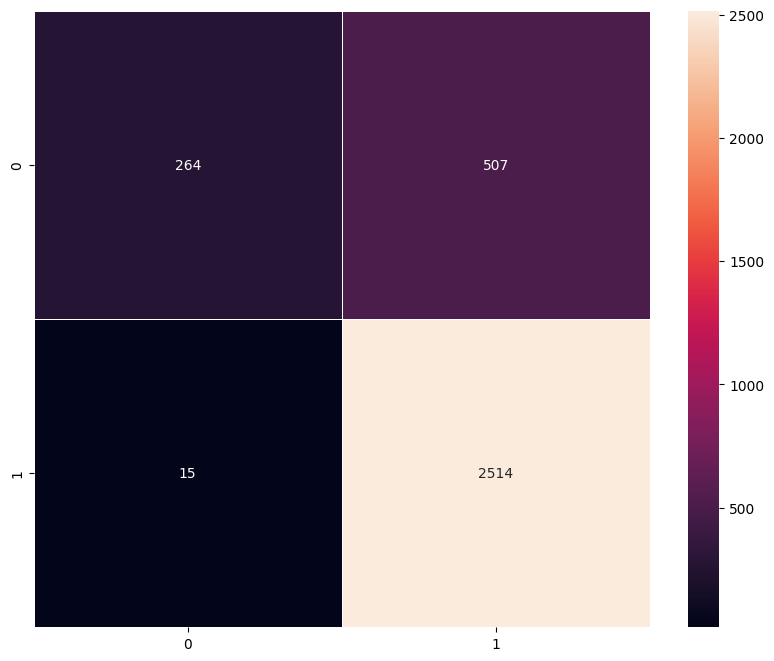

In [44]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

## Model 2: Transfer Learning with VGG-16 (Base)

In [47]:

# images_vgg = [cv2.resize(img, (64, 64), interpolation=cv2.INTER_AREA) for img in images]
# images_vgg = np.array(images_vgg)

vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
from tensorflow.keras.applications.vgg16 import preprocess_input

X_train_normalized = preprocess_input(X_train.astype('float32'))
X_val_normalized   = preprocess_input(X_val.astype('float32'))
X_test_normalized  = preprocess_input(X_test.astype('float32'))


In [80]:

model_2 = Sequential()
model_2.add(vgg_model)
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))

In [81]:
model_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [51]:
train_datagen = ImageDataGenerator()

In [52]:

model_2_history = model_vgg.fit(
    train_datagen.flow(X_train_normalized, y_train_encoded, batch_size=32, seed=42),
    epochs=20,
    steps_per_epoch=X_train_normalized.shape[0] // 32,
    validation_data=(X_val_normalized, y_val_encoded),
    verbose=1
)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.8791 - loss: 0.4372 - val_accuracy: 0.9442 - val_loss: 0.1201
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0482 - val_accuracy: 0.9296 - val_loss: 0.1643
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9480 - loss: 0.1365 - val_accuracy: 0.9636 - val_loss: 0.0844
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - loss: 0.0480 - val_accuracy: 0.9636 - val_loss: 0.0866
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9706 - loss: 0.0839 - val_accuracy: 0.9684 - val_loss: 0.0898
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0253 - val_accuracy: 0.9684 - val_loss: 0.0842
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9854 - loss: 0.0416 - val_accuracy: 0.9660 - val_loss: 0.0739
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accurac

### Visualizing the predictions

In [55]:
model_2_train_perf = model_performance_classification(model_vgg, X_train_normalized, y_train)
model_2_val_perf = model_performance_classification(model_vgg, X_val_normalized, y_val)

print("Train performance metrics")
print(model_2_train_perf)

print("Val performance metrics")
print(model_2_val_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.992727  0.992727   0.992727  0.992727
Val performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.968447  0.968447   0.968447  0.968447


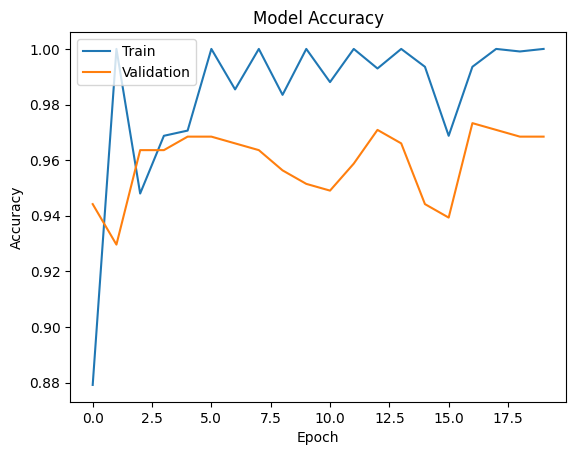

In [61]:
line_graph(model_2_history)

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [62]:
x = Flatten()(vgg_model.output)
x = Dense(256, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(128, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(64, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(32, activation='relu', kernel_initializer='he_uniform')(x)
output = Dense(1, activation='sigmoid')(x)


In [63]:
model_3 = Model(inputs=vgg_model.input, outputs=output)

model_3.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history_3 = model_3.fit(
    X_train_normalized, y_train_encoded,
    validation_data=(X_val_normalized, y_val_encoded),
    batch_size=32,
    epochs=20,
    verbose=2
)

Epoch 1/20
104/104 - 18s - 174ms/step - accuracy: 0.7742 - loss: 0.5835 - val_accuracy: 0.7913 - val_loss: 0.3505
Epoch 2/20
104/104 - 7s - 64ms/step - accuracy: 0.8645 - loss: 0.3054 - val_accuracy: 0.8883 - val_loss: 0.2645
Epoch 3/20
104/104 - 7s - 63ms/step - accuracy: 0.9097 - loss: 0.2255 - val_accuracy: 0.8883 - val_loss: 0.2494
Epoch 4/20
104/104 - 7s - 63ms/step - accuracy: 0.9079 - loss: 0.2502 - val_accuracy: 0.9102 - val_loss: 0.1939
Epoch 5/20
104/104 - 6s - 62ms/step - accuracy: 0.9252 - loss: 0.2007 - val_accuracy: 0.8689 - val_loss: 0.3143
Epoch 6/20
104/104 - 6s - 61ms/step - accuracy: 0.9288 - loss: 0.1752 - val_accuracy: 0.9126 - val_loss: 0.2085
Epoch 7/20
104/104 - 6s - 59ms/step - accuracy: 0.9364 - loss: 0.1520 - val_accuracy: 0.9248 - val_loss: 0.1972
Epoch 8/20
104/104 - 6s - 60ms/step - accuracy: 0.9218 - loss: 0.1886 - val_accuracy: 0.9248 - val_loss: 0.1936
Epoch 9/20
104/104 - 6s - 59ms/step - accuracy: 0.9300 - loss: 0.1673 - val_accuracy: 0.8981 - val_los

In [64]:



model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)
model_3_val_perf = model_performance_classification(model_3, X_val_normalized, y_val)

print("Train performance metrics")
print(model_3_train_perf)

print("Val performance metrics")
print(model_3_val_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.975152  0.975152   0.975152  0.975152
Val performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.936893  0.936893   0.936893  0.936893


#### Visualizing the predictions

In [65]:

model_3_train_perf = model_performance_classification(model_3, X_test_normalized, y_test)
print(model_3_train_perf)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
   Accuracy    Recall  Precision  F1 Score
0  0.932203  0.932203   0.932203  0.932203


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


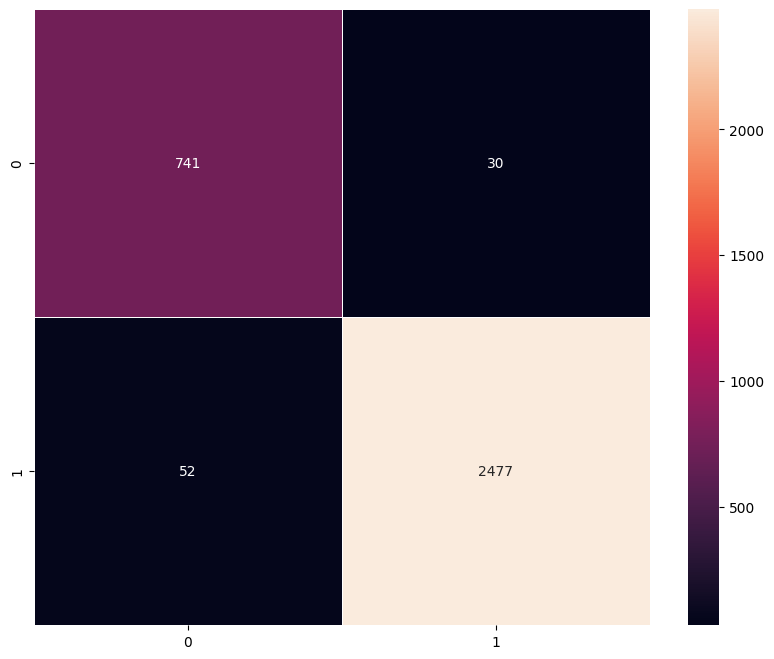

In [66]:
plot_confusion_matrix(model_3, X_train_normalized, y_train)

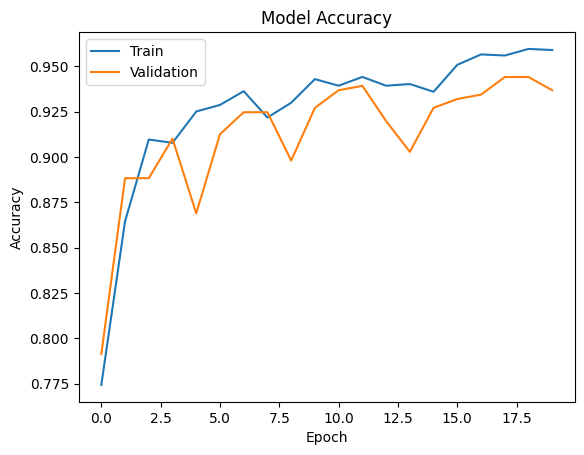

In [69]:
line_graph(history_3)

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

In [70]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=False,
    height_shift_range=0.1,
    width_shift_range=0.1,
    rotation_range=15,
    shear_range=0.1,
    zoom_range=0.1
)




In [71]:
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

In [72]:
x = Flatten()(vgg_model.output)
x = Dense(256, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(128, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(64, activation='relu', kernel_initializer='he_uniform')(x)
x = Dense(32, activation='relu', kernel_initializer='he_uniform')(x)
output = Dense(1, activation='sigmoid')(x)



In [73]:
model_4 = Model(inputs=vgg_model.input, outputs=output)

model_4.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history_4 = model_4.fit(
    train_datagen.flow(X_train_normalized, y_train_encoded, batch_size=32),
    validation_data=(X_val_normalized, y_val_encoded),
    epochs=20,
    verbose=2
)


Epoch 1/20
104/104 - 18s - 173ms/step - accuracy: 0.7579 - loss: 12.2851 - val_accuracy: 0.8034 - val_loss: 0.4017
Epoch 2/20
104/104 - 11s - 102ms/step - accuracy: 0.8264 - loss: 0.3715 - val_accuracy: 0.8981 - val_loss: 0.2578
Epoch 3/20
104/104 - 11s - 102ms/step - accuracy: 0.8812 - loss: 0.2891 - val_accuracy: 0.8641 - val_loss: 0.2736
Epoch 4/20
104/104 - 11s - 101ms/step - accuracy: 0.9033 - loss: 0.2415 - val_accuracy: 0.8956 - val_loss: 0.2236
Epoch 5/20
104/104 - 10s - 95ms/step - accuracy: 0.9018 - loss: 0.2325 - val_accuracy: 0.8859 - val_loss: 0.2515
Epoch 6/20
104/104 - 11s - 101ms/step - accuracy: 0.9215 - loss: 0.2051 - val_accuracy: 0.9272 - val_loss: 0.1696
Epoch 7/20
104/104 - 11s - 102ms/step - accuracy: 0.9173 - loss: 0.1965 - val_accuracy: 0.9150 - val_loss: 0.2294
Epoch 8/20
104/104 - 12s - 111ms/step - accuracy: 0.9155 - loss: 0.1981 - val_accuracy: 0.9442 - val_loss: 0.1568
Epoch 9/20
104/104 - 11s - 102ms/step - accuracy: 0.9379 - loss: 0.1593 - val_accuracy: 

In [74]:

model_4_train_perf = model_performance_classification(model_4, X_train_normalized, y_train)
model_4_val_perf = model_performance_classification(model_4, X_val_normalized, y_val)

print("Train performance metrics")
print(model_4_train_perf)

print("Val performance metrics")
print(model_4_val_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.967879  0.967879   0.967879  0.967879
Val performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.949029  0.949029   0.949029  0.949029


#### Visualizing the predictions

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


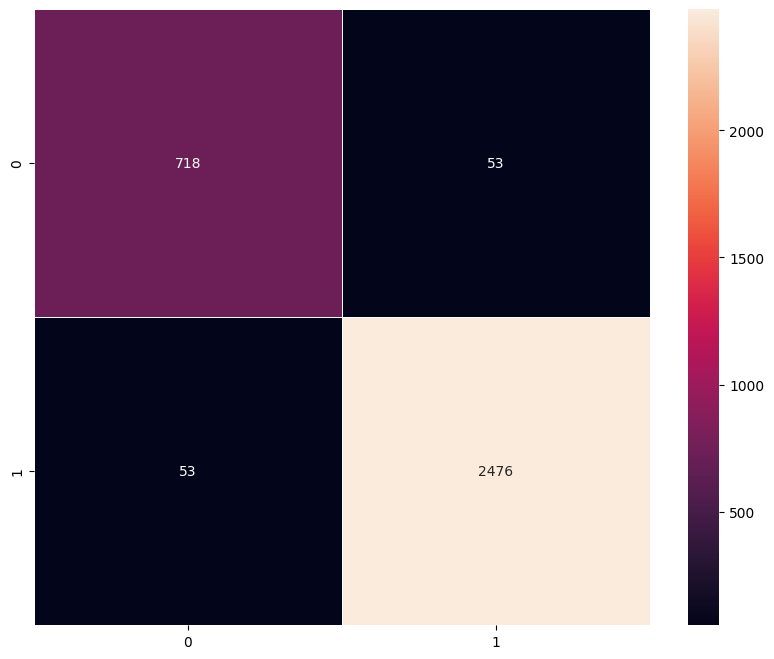

In [75]:
plot_confusion_matrix(model_4, X_train_normalized, y_train)

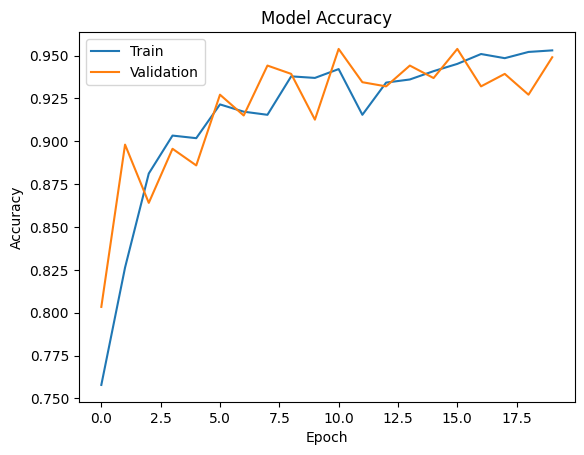

In [77]:
line_graph(history_4)

# **Model Performance Comparison and Final Model Selection**

In [84]:
models = {
    'Model 1 - FFNN':                model_1,
     'Model 2 - VGG16 Base':          model_2,
    'Model 3 - VGG16 + FFNN':        model_3,
     'Model 4 - VGG16 + FFNN + Aug':  model_4,
}

results = []
for name, model in models.items():
    expected_shape = model.input_shape[1:3]
    if expected_shape != X_test_normalized.shape[1:3]:
        X_test_data = np.array([cv2.resize(img, expected_shape) for img in X_test]).astype('float32') / 255.0
    else:
        X_test_data = X_test_normalized

    perf = model_performance_classification(model, X_test_data, y_test)
    perf.insert(0, 'Model', name)
    results.append(perf)

comparison_df = pd.concat(results, ignore_index=True)
print(comparison_df)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
                          Model  Accuracy    Recall  Precision  F1 Score
0                Model 1 - FFNN  0.854722  0.854722   0.854722  0.854722
1          Model 2 - VGG16 Base  0.670702  0.670702   0.670702  0.670702
2        Model 3 - VGG16 + FFNN  0.932203  0.932203   0.932203  0.932203
3  Model 4 - VGG16 + FFNN + Aug  0.939467  0.939467   0.939467  0.939467


Among the four models evaluated, Model 4 (VGG16 + FFNN + Augmentation) achieves the highest
performance across all metrics with an accuracy and F1 score of 93.9%.

In a helmet detection safety, minimising false negatives is critical Model 4's superior recall
of 93.9% means it correctly identifies the vast majority of helmet violations, outperforming
the baseline FFNN (85.5%), VGG16 alone (67.1%), and the non-augmented VGG16 + FFNN (93.2%).

The improvement from Model 3 to Model 4 also demonstrates that data augmentation meaningfully
boosts generalisation, suggesting the model is less likely to overfit on unseen data going forward.

## Test Performance

In [88]:
models = {
    'Model 1 - FFNN':               model_1,
    'Model 2 - VGG16 Base':         model_2,
    'Model 3 - VGG16 + FFNN':       model_3,
    'Model 4 - VGG16 + FFNN + Aug': model_4,
}

results = []
for name, model in models.items():
    perf = model_performance_classification(model, X_test_normalized, y_test)
    perf.insert(0, 'Model', name)
    results.append(perf)

comparison_df = pd.concat(results, ignore_index=True)
print(comparison_df)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
                          Model  Accuracy    Recall  Precision  F1 Score
0                Model 1 - FFNN  0.854722  0.854722   0.854722  0.854722
1          Model 2 - VGG16 Base  0.670702  0.670702   0.670702  0.670702
2        Model 3 - VGG16 + FFNN  0.932203  0.932203   0.932203  0.932203
3  Model 4 - VGG16 + FFNN + Aug  0.939467  0.939467   0.939467  0.939467


Model 4 once again out performs the other models this time on the test data set.

# **Actionable Insights & Recommendations**

-Given the imbalance of those with a helmet on vs without a helmet. The model tends to be more biased in predicting helmet in images. This could be problematic for more unseen data because false negatives are more costly from a safety perspective.
-It appears that transfer learning with the image net pretrained weights is very good at prediction vs a starting from scratch. Adding in data augmentation also really improves the models performance.

I would stick to using model 4 over the other models. Prioritizing the highest recall score is most important for this use case.

<font size=5 color='blue'>Power Ahead!</font>
___

In [ ]:
!jupyter nbconvert --to html /content/YourNotebookName.ipynb